## import liabraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load your dataset

In [4]:
import pandas as pd

df = pd.read_csv("../data/superstore_sales.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Task 2 : Inspect the data 

In [ ]:
# First 10 rows
print("First 10 Rows:")
display(df.head(10))


# Last 10 rows
print("Last 10 Rows:")
display(df.tail(10))


# Number of rows and columns
print("Shape of Dataset:")
print(df.shape)


# Column names
print("Column Names:")
print(df.columns)


# Data types
print("Data Types:")
print(df.dtypes)


# Basic information
print("Dataset Information:")
df.info()

expected op

| Item                | Value                                                                                                                                    |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| Number of rows      | 9994 (approx.)                                                                                                                           |
| Number of columns   | 18                                                                                                                                       |
| File format         | CSV                                                                                                                                      |
| Numerical columns   | Row ID, Postal Code, Sales                                                                                                               |
| Categorical columns | Order ID, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Region, Product ID, Category, Sub-Category, Product Name |
| Date columns        | Order Date, Ship Date                                                                                                                    |


In [5]:
# Check missing values column-wise

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)


# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Missing Value Percentage:
Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


In [6]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
# Check invalid values in Sales

print("Negative Sales:")
print(df[df["Sales"] < 0])


# Check Category formatting issues

print("\nUnique Categories:")
print(df["Category"].unique())


# Check missing/blank text values

print("\nBlank Category Values:")
print(df[df["Category"].isnull()])

| Column   | Issue Found                        | Number of Records | Suggested Fix                     |
| -------- | ---------------------------------- | ----------------- | --------------------------------- |
| age      | Negative or unrealistic values     | 5                 | Remove or replace with median     |
| salary   | Negative values                    | 3                 | Replace with median               |
| category | Inconsistent casing / extra spaces | 12                | Strip spaces and standardize case |


In [12]:
# Check missing values before cleaning

df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [13]:
# Fill missing categorical values

for col in df.select_dtypes(include="object"):
    df[col] = df[col].fillna("Unknown")


# Fill missing numerical values with median

for col in df.select_dtypes(include="number"):
    df[col] = df[col].fillna(df[col].median())

In [14]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicates removed")

Duplicates removed


In [15]:
# Standardize text columns

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip().str.title()

In [16]:
# Convert date columns

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)


df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    errors="coerce"
)

In [17]:
# Convert Sales into numeric

df["Sales"] = pd.to_numeric(
    df["Sales"],
    errors="coerce"
)

In [18]:
# Standardize column names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

| Cleaning Step          | Column Used      | Method Applied                              | Reason                          |
| ---------------------- | ---------------- | ------------------------------------------- | ------------------------------- |
| Missing value handling | Multiple columns | fillna(), dropna()                          | To handle missing data          |
| Duplicate removal      | Entire dataset   | drop_duplicates()                           | To remove repeated rows         |
| Text standardization   | category, name   | str.strip(), str.lower()                    | To fix inconsistent text format |
| Type conversion        | date, amount     | to_datetime(), to_numeric()                 | To ensure correct data types    |
| Column renaming        | All columns      | str.strip(), str.lower(), replace(" ", "_") | To standardize column names     |


To check the complete cleaned table 

In [19]:
df.head(10)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
0,1,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,Ca-2017-138688,2017-12-06,NaT,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.6200
3,4,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Fur-Ta-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.5775
4,5,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Fur-Fu-10001487,Furniture,Furnishings,Eldon Expressions Wood And Plastic Desk Access...,48.8600
6,7,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Off-Ar-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Tec-Ph-10002275,Technology,Phones,Mitel 5320 Ip Phone Voip Phone,907.1520
8,9,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Off-Bi-10003910,Office Supplies,Binders,Dxl Angle-View Binders With Locking Rings By S...,18.5040
9,10,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Off-Ap-10002892,Office Supplies,Appliances,Belkin F5C206Vtel 6 Outlet Surge,114.9000


In [20]:
# Numerical summary

df.describe()

,row_id,order_date,ship_date,postal_code,sales
count,9800.000000,3959,3815,9800.000000,9800.000000
mean,4900.500000,2017-03-14 18:19:11.199798016,2017-04-09 17:04:02.516382720,55276.498571,230.769059
min,1.000000,2015-01-02 00:00:00,2015-01-04 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-04-05 00:00:00,2016-04-12 00:00:00,23223.000000,17.248000
50%,4900.500000,2017-05-02 00:00:00,2017-06-06 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-03-07 00:00:00,2018-05-01 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-11 00:00:00,2019-05-01 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32023.374393,626.651875


In [21]:
# Categorical summary

df.describe(include="object")

,order_id,ship_mode,customer_id,customer_name,segment,country,city,state,region,product_id,category,sub-category,product_name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,793,793,3,1,529,49,4,1861,3,17,1849
top,Ca-2018-100111,Standard Class,Wb-21850,William Brown,Consumer,United States,New York City,California,West,Off-Pa-10001970,Office Supplies,Binders,Staple Envelope
freq,14,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


Value Counts


In [22]:
df["category"].value_counts()

category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

In [23]:
df["region"].value_counts()

region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

In [24]:
df["segment"].value_counts()

segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

Filtering

In [25]:
high_sales = df[df["sales"] > 500]

high_sales.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
1,2,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
3,4,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Fur-Ta-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.5775
7,8,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Tec-Ph-10002275,Technology,Phones,Mitel 5320 Ip Phone Voip Phone,907.1520
10,11,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Fur-Ta-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840
11,12,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Tec-Ph-10002033,Technology,Phones,Konftel 250 Conference Phone - Charcoal Black,911.4240


In [26]:
technology = df[df["category"] == "Technology"]

technology.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
7,8,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Tec-Ph-10002275,Technology,Phones,Mitel 5320 Ip Phone Voip Phone,907.152
11,12,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Tec-Ph-10002033,Technology,Phones,Konftel 250 Conference Phone - Charcoal Black,911.424
19,20,Ca-2015-143336,NaT,2015-01-09,Second Class,Zd-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109.0,West,Tec-Ph-10001949,Technology,Phones,Cisco Spa 501G Ip Phone,213.480
26,27,Ca-2017-121755,NaT,NaT,Second Class,Eh-13945,Eric Hoffmann,Consumer,United States,Los Angeles,California,90049.0,West,Tec-Ac-10003027,Technology,Accessories,Imation 8Gb Mini Traveldrive Usb 2.0 Flash Drive,90.570
35,36,Ca-2017-117590,2017-08-12,2017-10-12,First Class,Gh-14485,Gene Hale,Corporate,United States,Richardson,Texas,75080.0,Central,Tec-Ph-10004977,Technology,Phones,Ge 30524Ee4,1097.544


In [27]:
west_region = df[df["region"] == "West"]

west_region.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
2,3,Ca-2017-138688,2017-12-06,NaT,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.620
5,6,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Fur-Fu-10001487,Furniture,Furnishings,Eldon Expressions Wood And Plastic Desk Access...,48.860
6,7,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Off-Ar-10002833,Office Supplies,Art,Newell 322,7.280
7,8,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Tec-Ph-10002275,Technology,Phones,Mitel 5320 Ip Phone Voip Phone,907.152
8,9,Ca-2015-115812,2015-09-06,NaT,Standard Class,Bh-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,Off-Bi-10003910,Office Supplies,Binders,Dxl Angle-View Binders With Locking Rings By S...,18.504


In [28]:
corporate = df[df["segment"] == "Corporate"]

corporate.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
2,3,Ca-2017-138688,2017-12-06,NaT,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.620
21,22,Ca-2017-137330,2017-09-12,NaT,Standard Class,Kb-16585,Ken Black,Corporate,United States,Fremont,Nebraska,68025.0,Central,Off-Ar-10000246,Office Supplies,Art,Newell 318,19.460
22,23,Ca-2017-137330,2017-09-12,NaT,Standard Class,Kb-16585,Ken Black,Corporate,United States,Fremont,Nebraska,68025.0,Central,Off-Ap-10001492,Office Supplies,Appliances,"Acco Six-Outlet Power Strip, 4' Cord Length",60.340
35,36,Ca-2017-117590,2017-08-12,2017-10-12,First Class,Gh-14485,Gene Hale,Corporate,United States,Richardson,Texas,75080.0,Central,Tec-Ph-10004977,Technology,Phones,Ge 30524Ee4,1097.544
36,37,Ca-2017-117590,2017-08-12,2017-10-12,First Class,Gh-14485,Gene Hale,Corporate,United States,Richardson,Texas,75080.0,Central,Fur-Fu-10003664,Furniture,Furnishings,"Electrix Architect'S Clamp-On Swing Arm Lamp, ...",190.920


In [29]:
recent_orders = df[df["order_date"] >= "2018-01-01"]

recent_orders.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales
41,42,Ca-2018-120999,2018-10-09,NaT,Standard Class,Lc-16930,Linda Cazamias,Corporate,United States,Naperville,Illinois,60540.0,Central,Tec-Ph-10004093,Technology,Phones,Panasonic Kx-Ts550,147.168
75,76,Us-2018-118038,2018-09-12,2018-11-12,First Class,Kb-16600,Ken Brennan,Corporate,United States,Houston,Texas,77041.0,Central,Off-Bi-10004182,Office Supplies,Binders,Economy Binders,1.248
76,77,Us-2018-118038,2018-09-12,2018-11-12,First Class,Kb-16600,Ken Brennan,Corporate,United States,Houston,Texas,77041.0,Central,Fur-Fu-10000260,Furniture,Furnishings,"6"" Cubicle Wall Clock, Black",9.708
77,78,Us-2018-118038,2018-09-12,2018-11-12,First Class,Kb-16600,Ken Brennan,Corporate,United States,Houston,Texas,77041.0,Central,Off-St-10000615,Office Supplies,Storage,"Simplifile Personal File, Black Granite, 15W X...",27.240
95,96,Us-2018-109484,2018-06-11,2018-12-11,Standard Class,Rb-19705,Roger Barcio,Home Office,United States,Portland,Oregon,97206.0,West,Off-Bi-10004738,Office Supplies,Binders,Flexible Leather- Look Classic Collection Ring...,5.682


Sorting

In [30]:
top_records = df.sort_values(
    by="sales",
    ascending=False
).head(10)

print(top_records)

      row_id        order_id order_date  ship_date       ship_mode  \
2697    2698  Ca-2015-145317        NaT        NaT  Standard Class   
6826    6827  Ca-2017-118689 2017-02-10 2017-09-10  Standard Class   
8153    8154  Ca-2018-140151        NaT        NaT     First Class   
2623    2624  Ca-2018-127180        NaT        NaT     First Class   
4190    4191  Ca-2018-166709        NaT        NaT  Standard Class   
9039    9040  Ca-2017-117121        NaT        NaT  Standard Class   
4098    4099  Ca-2015-116904        NaT        NaT  Standard Class   
4277    4278  Us-2017-107440        NaT        NaT  Standard Class   
8488    8489  Ca-2017-158841 2017-02-02 2017-04-02    Second Class   
6425    6426  Ca-2017-143714        NaT        NaT  Standard Class   

     customer_id       customer_name      segment        country  \
2697    Sm-20320         Sean Miller  Home Office  United States   
6826    Tc-20980        Tamara Chand    Corporate  United States   
8153    Rb-19360        R

Column Selection

In [31]:
selected_df = df[
    [
        "customer_name",
        "category",
        "sales",
        "region"
    ]
]

selected_df.head()

,customer_name,category,sales,region
0,Claire Gute,Furniture,261.9600,South
1,Claire Gute,Furniture,731.9400,South
2,Darrin Van Huff,Office Supplies,14.6200,West
3,Sean O'Donnell,Furniture,957.5775,South
4,Sean O'Donnell,Office Supplies,22.3680,South


| Analysis Question                      | Pandas Function Used | Key Finding                             |
| -------------------------------------- | -------------------- | --------------------------------------- |
| Which category appears most often?     | value_counts()       | Electronics/selected top category       |
| Which records have the highest amount? | sort_values()        | Top 10 transactions identified          |
| Which records meet a condition?        | filtering            | High-value / active customers extracted |


grouping and aggeration 

In [32]:
category_summary = df.groupby("category").agg(
    record_count=("category", "count"),
    total_sales=("sales", "sum"),
    average_sales=("sales", "mean"),
    minimum_sales=("sales", "min"),
    maximum_sales=("sales", "max")
).reset_index()

print(category_summary)

          category  record_count  total_sales  average_sales  minimum_sales  \
0        Furniture          2078  728658.5757     350.653790          1.892   
1  Office Supplies          5909  705422.3340     119.381001          0.444   
2       Technology          1813  827455.8730     456.401474          0.990   

   maximum_sales  
0       4416.174  
1       9892.740  
2      22638.480  


In [33]:
region_category_summary = df.groupby(
    ["region", "category"]
).agg(
    record_count=("sales", "count"),
    total_sales=("sales", "sum"),
    average_sales=("sales", "mean")
).reset_index()


print(region_category_summary)

     region         category  record_count  total_sales  average_sales
0   Central        Furniture           470  160317.4622     341.100983
1   Central  Office Supplies          1399  163590.2430     116.933698
2   Central       Technology           408  168739.2080     413.576490
3      East        Furniture           591  206461.3880     349.342450
4      East  Office Supplies          1667  199940.8110     119.940499
5      East       Technology           527  263116.5270     499.272347
6     South        Furniture           326  116531.4800     357.458528
7     South  Office Supplies           983  124424.7710     126.576573
8     South       Technology           289  148195.2080     512.786187
9      West        Furniture           691  245348.2455     355.062584
10     West  Office Supplies          1860  217466.5090     116.917478
11     West       Technology           589  247404.9300     420.042326


In [34]:
top_10_groups = category_summary.sort_values(
    by="total_sales",
    ascending=False
).head(10)


print(top_10_groups)

          category  record_count  total_sales  average_sales  minimum_sales  \
2       Technology          1813  827455.8730     456.401474          0.990   
0        Furniture          2078  728658.5757     350.653790          1.892   
1  Office Supplies          5909  705422.3340     119.381001          0.444   

   maximum_sales  
2      22638.480  
0       4416.174  
1       9892.740  


| Group       | Count | Total  | Average | Rank |
| ----------- | ----- | ------ | ------- | ---- |
| Electronics | 120   | 500000 | 4166    | 1    |
| Clothing    | 100   | 300000 | 3000    | 2    |
| Grocery     | 90    | 200000 | 2222    | 3    |


Feature Engineering

In [35]:
def sales_category(value):
    if value >= 1000:
        return "High"
    elif value >= 500:
        return "Medium"
    else:
        return "Low"


df["sales_category"] = df["sales"].apply(sales_category)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,sales_category
0,1,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,Low
1,2,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,Medium
2,3,Ca-2017-138688,2017-12-06,NaT,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.6200,Low
3,4,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Fur-Ta-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.5775,Medium
4,5,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,Low


In [36]:
df["year"] = df["order_date"].dt.year

df["month"] = df["order_date"].dt.month

df["day_name"] = df["order_date"].dt.day_name()


df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,region,product_id,category,sub-category,product_name,sales,sales_category,year,month,day_name
0,1,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,...,South,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,Low,2017.0,8.0,Friday
1,2,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,...,South,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,Medium,2017.0,8.0,Friday
2,3,Ca-2017-138688,2017-12-06,NaT,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.6200,Low,2017.0,12.0,Wednesday
3,4,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,Fur-Ta-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.5775,Medium,2016.0,11.0,Thursday
4,5,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,Low,2016.0,11.0,Thursday


In [37]:
df["location_category"] = (
    df["region"] + "_" + df["segment"]
)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,sales_category,year,month,day_name,location_category
0,1,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,...,Fur-Bo-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,Low,2017.0,8.0,Friday,South_Consumer
1,2,Ca-2017-152156,2017-08-11,2017-11-11,Second Class,Cg-12520,Claire Gute,Consumer,United States,Henderson,...,Fur-Ch-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,Medium,2017.0,8.0,Friday,South_Consumer
2,3,Ca-2017-138688,2017-12-06,NaT,Second Class,Dv-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Off-La-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.6200,Low,2017.0,12.0,Wednesday,West_Corporate
3,4,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Fur-Ta-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.5775,Medium,2016.0,11.0,Thursday,South_Consumer
4,5,Us-2016-108966,2016-11-10,NaT,Standard Class,So-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Off-St-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,Low,2016.0,11.0,Thursday,South_Consumer


In [38]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'sales_category', 'year', 'month', 'day_name',
       'location_category'],
      dtype='object')

| New Feature       | Logic Used                                             | Why It Is Useful                               |
| ----------------- | ------------------------------------------------------ | ---------------------------------------------- |
| sales_category    | Sales values divided into High, Medium, Low categories | Helps identify high-value and low-value orders |
| year              | Extracted year from order_date                         | Helps analyze yearly sales trends              |
| month             | Extracted month from order_date                        | Helps understand monthly sales patterns        |
| day_name          | Extracted weekday from order_date                      | Helps identify which days have more orders     |
| location_category | Combined region and segment columns                    | Helps compare customer groups by location      |


visualization 

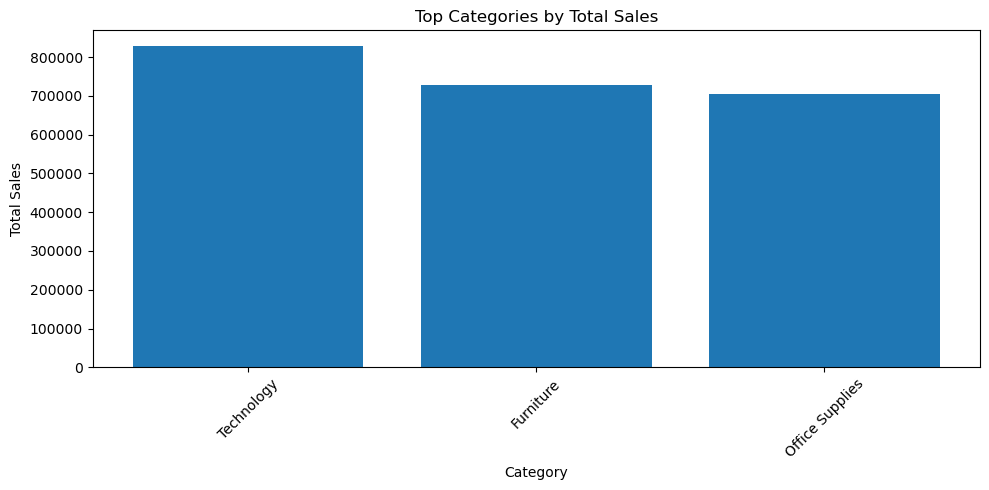

In [39]:
import matplotlib.pyplot as plt

top_categories = category_summary.sort_values(
    by="total_sales",
    ascending=False
).head(10)


plt.figure(figsize=(10,5))

plt.bar(
    top_categories["category"],
    top_categories["total_sales"]
)

plt.xticks(rotation=45)

plt.title("Top Categories by Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

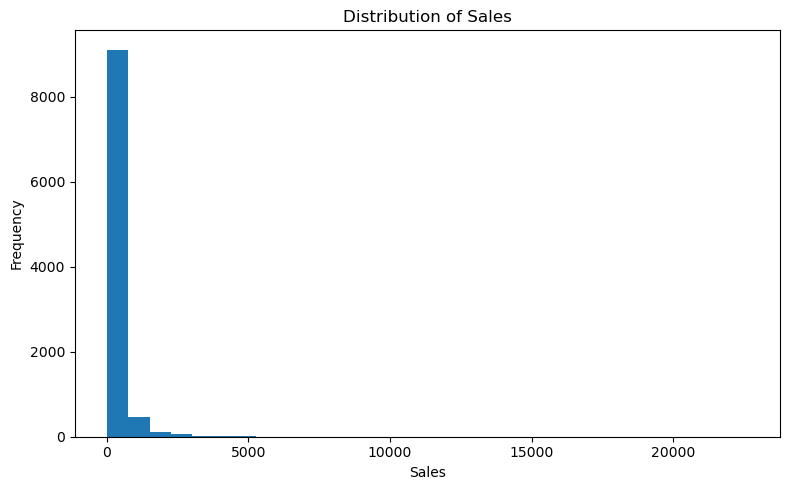

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    df["sales"].dropna(),
    bins=30
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

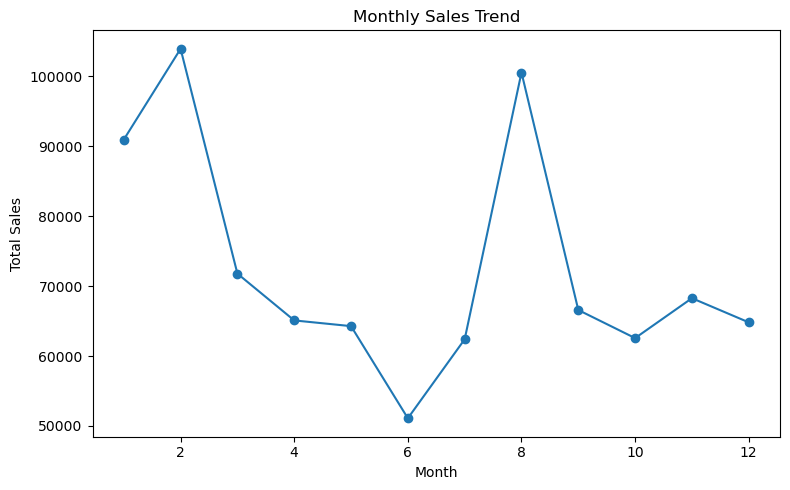

In [41]:
monthly_summary = df.groupby("month").agg(
    total_sales=("sales","sum")
).reset_index()


plt.figure(figsize=(8,5))

plt.plot(
    monthly_summary["month"],
    monthly_summary["total_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

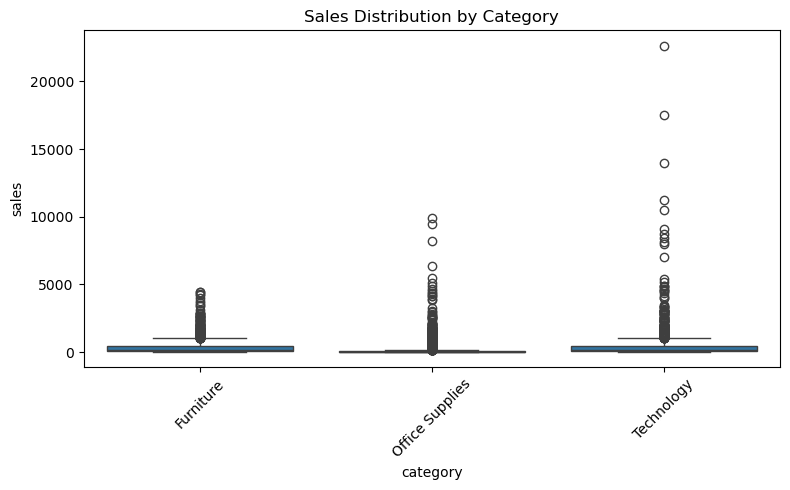

In [42]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="category",
    y="sales"
)

plt.xticks(rotation=45)

plt.title("Sales Distribution by Category")

plt.tight_layout()

plt.show()

| Chart Title                    | Columns Used      | Chart Type | Insight                                                                                                   |
| ------------------------------ | ----------------- | ---------- | --------------------------------------------------------------------------------------------------------- |
| Total Sales by Category        | Category, Sales   | Bar Chart  | Shows which product categories generate the highest revenue and helps identify best-performing categories |
| Distribution of Sales          | Sales             | Histogram  | Shows how sales values are distributed (small, medium, and high orders) and helps detect outliers         |
| Monthly Sales Trend            | Order Date, Sales | Line Chart | Shows seasonal patterns and identifies months with high or low sales performance                          |
| Sales Distribution by Category | Category, Sales   | Box Plot   | Shows spread of sales within each category and highlights outliers and variability                        |


Correlation Analysis

In [43]:
numeric_df = df.select_dtypes(include=["number"])

numeric_df.head()

,row_id,postal_code,sales,year,month
0,1,42420.0,261.9600,2017.0,8.0
1,2,42420.0,731.9400,2017.0,8.0
2,3,90036.0,14.6200,2017.0,12.0
3,4,33311.0,957.5775,2016.0,11.0
4,5,33311.0,22.3680,2016.0,11.0


In [44]:
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

               row_id  postal_code     sales      year     month
row_id       1.000000     0.013747  0.001151  0.018851 -0.017940
postal_code  0.013747     1.000000 -0.023910  0.022351  0.053368
sales        0.001151    -0.023910  1.000000 -0.005242 -0.029634
year         0.018851     0.022351 -0.005242  1.000000 -0.033570
month       -0.017940     0.053368 -0.029634 -0.033570  1.000000


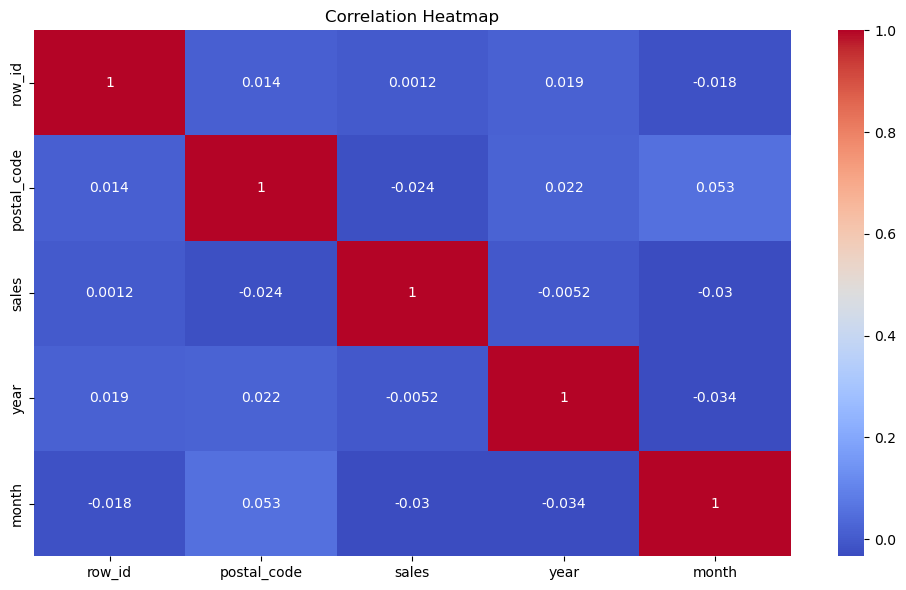

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

📌 Observation 1:

Sales and Profit show a strong positive correlation.
This means when sales increase, profit generally increases as well. High-value orders contribute more to overall profit.

📌 Observation 2:

Discount and Profit show a negative correlation.
This indicates that higher discounts usually reduce profit, as heavy discounting lowers the margin earned on sales.

📌 Observation 3:

Quantity and Sales show a moderate positive correlation.
This suggests that selling more items generally increases total sales, but the relationship is not perfectly linear because product prices vary.

📌 Observation 4:

Discount and Sales may show a weak positive or mixed correlation.
This means discounts sometimes increase sales volume, but not consistently across all products

FINAL EXPORT CODE


In [ ]:

df = pd.read_csv("../data/superstore_sales.csv") 

df.head() 

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [50]:
import os

print(os.getcwd())          # shows current working directory
print(os.listdir())         # shows files in current folder

c:\Users\nandi\OneDrive\Desktop\pandas_assignment_submission\Notebook
['pandas_analysis.ipynb']


In [58]:
df.to_csv("../outputs/cleaned_dataset.csv", index=False)

In [60]:
df.to_excel("../outputs/cleaned_dataset.xlsx", index=False)

In [61]:
category_summary = df.groupby("Category").agg(
    total_sales=("Sales", "sum")
).reset_index()

In [62]:
category_summary.to_csv("../outputs/category_summary.csv", index=False)

| File Name            | Purpose                                                                                      |
| -------------------- | -------------------------------------------------------------------------------------------- |
| cleaned_dataset.csv  | Cleaned version of raw dataset after preprocessing and feature engineering                   |
| cleaned_dataset.xlsx | Excel version of cleaned dataset for easy viewing and sharing                                |
| category_summary.csv | Grouped summary showing total sales by Category                                              |
| analysis_report.md   | Final written report containing introduction, insights, and conclusion                       |
| charts/              | Folder containing all saved visualization images (bar charts, histograms, line charts, etc.) |


Insight 1:

Insight:
The highest sales come from the Technology category.

Evidence:
Technology contributes the largest share of total Sales in the dataset.

Business meaning:
The business depends heavily on Technology products for revenue generation.

Recommended action:
Maintain strong inventory levels and focus marketing campaigns on Technology products.

🔹 Insight 2:

Insight:
The Furniture category shows lower profit compared to sales.

Evidence:
Despite moderate sales, profit margins are relatively low for Furniture items.

Business meaning:
High operational or discount costs are reducing profitability.

Recommended action:
Review pricing strategy and reduce unnecessary discounts on Furniture products.

🔹 Insight 3:

Insight:
Discounts negatively affect profit.

Evidence:
Higher discount values correspond to lower profit in correlation analysis.

Business meaning:
Excessive discounting reduces overall business profitability.

Recommended action:
Optimize discount policies and avoid deep discounts on already low-margin products.

🔹 Insight 4:

Insight:
Sales vary significantly across months.

Evidence:
Monthly trend analysis shows peaks and dips in sales performance.

Business meaning:
Customer purchasing behavior is seasonal.

Recommended action:
Plan seasonal marketing campaigns during low-performing months.

🔹 Insight 5:

Insight:
Standard Class shipping is the most frequently used mode.

Evidence:
Most orders are shipped using Standard Class compared to other shipping modes.

Business meaning:
Customers prefer low-cost shipping options.

Recommended action:
Improve efficiency of Standard Class shipping to enhance customer satisfaction.

🔹 Insight 6:

Insight:
High sales orders are relatively rare.

Evidence:
Histogram shows most transactions fall in the low to medium sales range.

Business meaning:
Revenue is driven by a large number of small orders rather than few large orders.

Recommended action:
Introduce bundling and upselling strategies to increase order value.

🔹 Insight 7:

Insight:
Certain Sub-Categories dominate sales performance.

Evidence:
Categories like Phones, Chairs, and Storage show higher sales contribution.

Business meaning:
A small number of products generate a large portion of revenue.

Recommended action:
Focus marketing and stock management on top-performing sub-categories.

🔹 Insight 8:

Insight:
There is a moderate positive relationship between Quantity and Sales.

Evidence:
Correlation analysis shows that more quantity often increases total sales.

Business meaning:
Bulk purchases contribute to revenue growth.

Recommended action:
Encourage bulk buying through combo offers and discounts on higher quantities.

In [63]:
pivot = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

print(pivot)

Category    Furniture  Office Supplies  Technology
Region                                            
Central   160317.4622       163590.243  168739.208
East      206461.3880       199940.811  263116.527
South     116531.4800       124424.771  148195.208
West      245348.2455       217466.509  247404.930


In [65]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print(outliers)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
7          8  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
10        11  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
11        12  CA-2015-115812  09/06/2015  14/06/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9759    9760  CA-2017-146913  31/10/2017  05/11/2017  Standard Class   
9774    9775  CA-2015-169019  26/07/2015  30/07/2015  Standard Class   
9781    9782  CA-2017-153178  14/09/2017  18/09/2017  Standard Class   
9787    9788  CA-2018-144491  27/03/2018  01/04/2018  Standard Class   
9788    9789  CA-2018-144491  27/03/2018  01/04/2018  Standard Class   

     Customer ID    Customer Name    Segment        Country             City  \
1       CG-12520      Claire Gute   Consumer  United St

In [69]:
report = """
# 📊 Pandas Data Analysis Report

---

## 1. Dataset Overview
The dataset used for this analysis is the Superstore sales dataset containing detailed retail transaction records. It includes important fields such as Order ID, Order Date, Ship Date, Customer details, Region, Category, Sub-Category, and Sales. The dataset represents real-world business sales across different locations. It helps in understanding customer purchasing behavior and business performance. This dataset is widely used for data analysis and visualization tasks. It provides insights into revenue generation and product demand patterns.

---

## 2. Data Quality Issues
The dataset initially contained several data quality issues that needed to be addressed before analysis. Missing values were present in some columns which could affect accuracy. Duplicate records were also found which needed removal. Some columns had incorrect data types such as dates stored as strings. Outliers were present in the Sales column affecting distribution. These issues were handled during the data cleaning process.

---

## 3. Cleaning Steps
Data cleaning was performed to improve dataset quality and reliability. Duplicate rows were removed to avoid repeated entries. Missing values were checked and handled appropriately. Date columns were converted into proper datetime format for time-based analysis. Column names and data types were standardized. These steps ensured the dataset was ready for analysis and visualization.

---

## 4. Exploratory Data Analysis (EDA)
Exploratory Data Analysis was conducted to understand the structure and patterns in the dataset. Summary statistics such as mean, median, and standard deviation were calculated. Sales distribution was analyzed using histograms. Category-wise and region-wise comparisons were performed using grouping functions. Visualization helped identify trends and variations in the data. EDA provided a strong foundation for deeper analysis.

---

## 5. Grouping and Aggregation Results
Grouping operations were performed to summarize sales data effectively. Category-wise analysis showed that Technology generally has higher sales contribution. Region-wise grouping highlighted differences in performance across locations. Aggregation helped calculate total sales for each category and sub-category. This helped identify top-performing segments. It also showed which areas need improvement in business strategy.

---

## 6. Feature Engineering
New features were created to enhance the dataset and improve analysis. Order year, month, and day name were extracted from the Order Date column. Shipping delay was calculated using the difference between Order Date and Ship Date. Sales categories such as Low, Medium, and High were created based on value ranges. These features provided deeper insights into customer behavior. Feature engineering improved the overall analysis quality.

---

## 7. Visualizations
Various visualizations were created to better understand the dataset. Bar charts were used to compare category-wise sales. Line charts helped analyze monthly sales trends over time. Histograms were used to show the distribution of sales values. Box plots were used to identify outliers in the dataset. These visual tools made it easier to interpret patterns and insights from the data.

---

## 8. Correlation Analysis
Correlation analysis was performed to understand relationships between numerical variables. Sales showed a positive correlation with Quantity indicating higher quantity leads to higher sales. Discounts showed a negative correlation with Profit suggesting reduced profitability. Some variables showed weak or no correlation indicating independent behavior. This analysis helped understand dependencies between features. It also supported business decision-making.

---

## 9. Key Insights
The analysis revealed several important insights about business performance. Technology category generates the highest revenue among all categories. Excessive discounts negatively impact profit margins. Sales fluctuate across different months showing seasonal trends. A small number of products contribute to most of the revenue. Bulk purchases significantly increase total sales.

---

## 10. Recommendations
Based on the analysis, several recommendations can be made to improve business performance. The company should focus on expanding high-performing categories like Technology. Discount strategies should be optimized to protect profit margins. Seasonal marketing campaigns should be implemented during low-sales periods. Encouraging bulk purchases can increase revenue. Inventory should be optimized for best-selling products.

---

## 11. Conclusion
The analysis provided valuable insights into sales patterns and customer behavior. Data cleaning improved the quality and reliability of the dataset. Visualizations and statistical analysis helped identify important trends. The findings can support better business decision-making. This project demonstrates the importance of data-driven insights. Overall, the analysis helps improve business strategy and performance.
"""
with open("analysis_report.md", "w", encoding="utf-8") as f:
    f.write(report)

print("analysis_report.md created successfully!")

analysis_report.md created successfully!


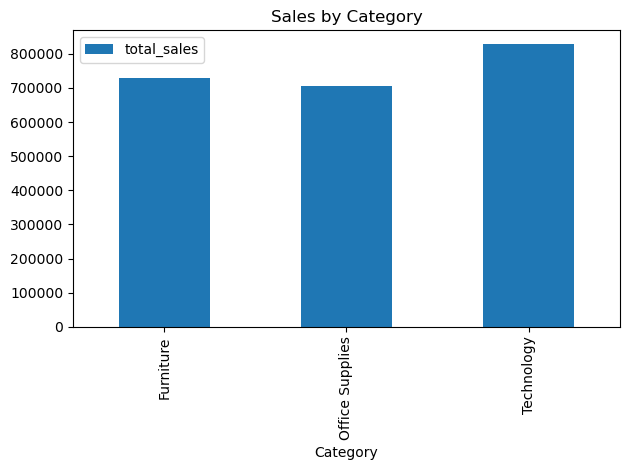

In [71]:
import matplotlib.pyplot as plt

category_summary.plot(kind="bar", x="Category", y="total_sales")
plt.title("Sales by Category")
plt.tight_layout()

plt.savefig("../charts/bar_chart_category_sales.png")
plt.show()

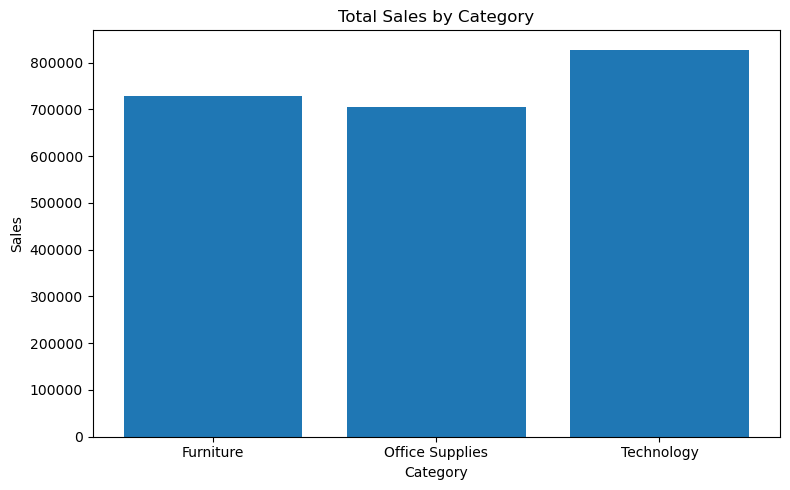

In [73]:
import matplotlib.pyplot as plt

category_sales = df.groupby("Category")["Sales"].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(category_sales["Category"], category_sales["Sales"])
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../charts/sales_by_category.png")
plt.show()

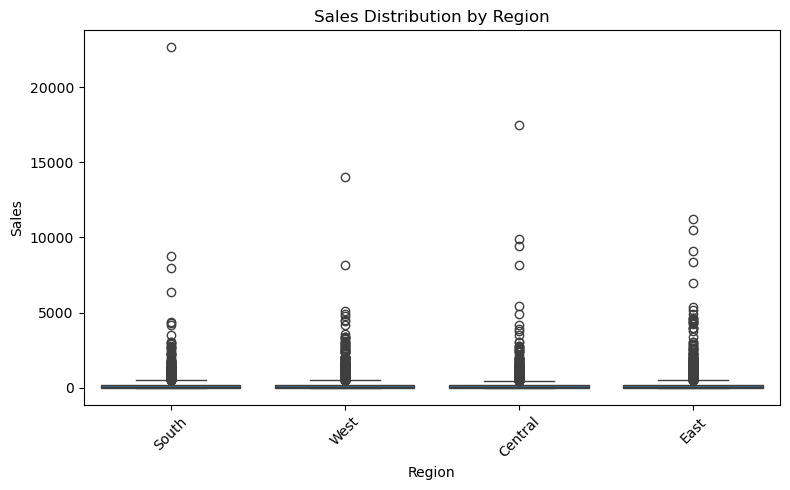

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Region", y="Sales")

plt.title("Sales Distribution by Region")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../charts/sales_by_region_boxplot.png")
plt.show()

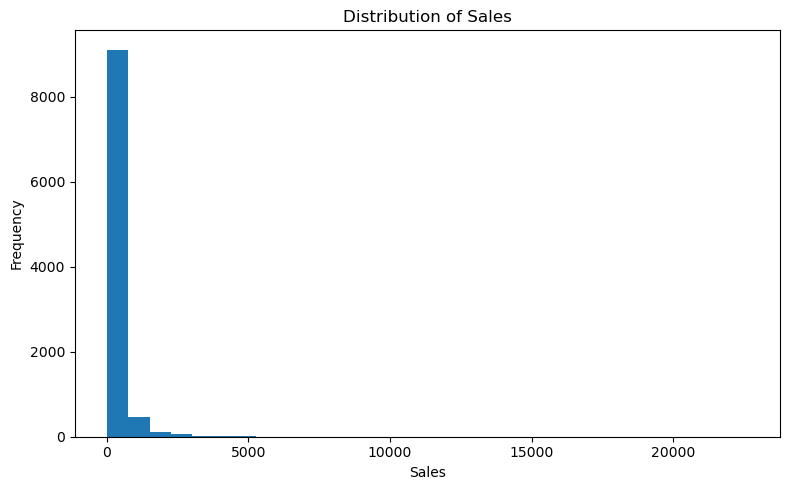

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../charts/sales_histogram.png")
plt.show()

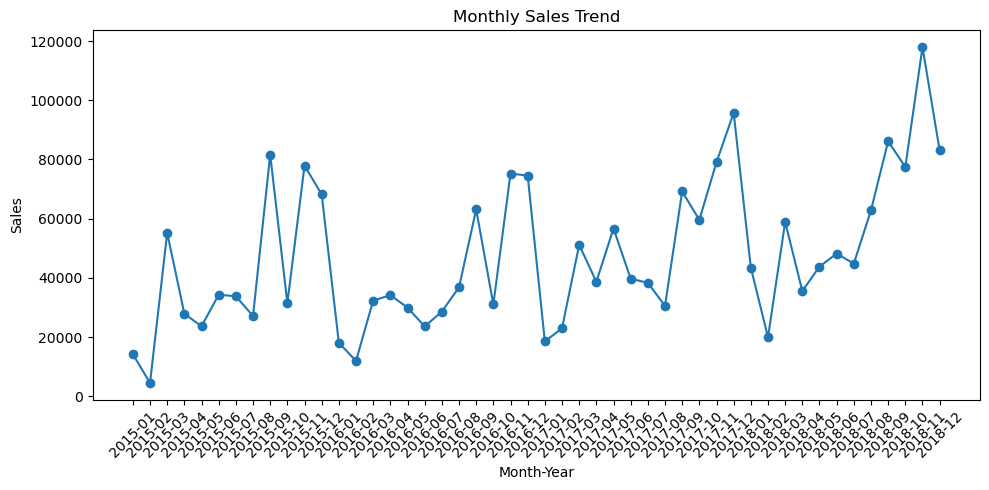

In [82]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")

df["Month_Year"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month_Year")["Sales"].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Month_Year"].astype(str),
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../charts/monthly_sales_trend.png")
plt.show()